# Faculdade de Informática e Administração Paulista(FIAP)
POSTECH Data Analytics - BB 

---
Disciplina: Fase 2 - Machine Learning and Time Serie \
Turma: 1DTAT BB  - Período: 24/06/2025 à 30/08/2025 

1 - Desafio 

#### TECH CHALLENGE
Tech Challenge é o projeto que englobará os conhecimentos obtidos em
todas as disciplinas da fase. Esta é uma atividade que, em princípio, deve ser
desenvolvida em grupo. Importante atentar-se ao prazo de entrega, pois trata-se
de uma atividade obrigatória, uma vez que sua pontuação se refere a 90% da
nota final.

##### O problema
Você foi recentemente alocado em uma equipe de cientistas de dados de
um grande fundo de investimentos brasileiro. Sua missão inicial é desenvolver
um modelo preditivo capaz de prever se o índice IBOVESPA vai fechar em alta
ou baixa no dia seguinte, com base em dados históricos do próprio índice. Esse
modelo será usado como insumo para alimentar dashboards internos de tomada
de decisão dos analistas quantitativos da empresa.

##### Dados
Utilize os dados históricos do índice IBOVESPA, disponíveis
publicamente: https://br.investing.com/indices/bovespa-historical-data
Requisitos:
- Selecione o período “diário”.
- Baixe um intervalo de pelo menos 2 anos de dados.
- Realize o pré-processamento necessário para utilizar os dados no
modelo.
Objetivo
Criar um modelo que preveja se o fechamento do IBOVESPA do dia
seguinte será maior ou menor que o do dia atual, ou seja:

| dia| fechamento | tendência | 
|----:|:----------|:----------|
| 1  | 120.000    | -         |
| 2  | 120.500    | ↑         |
| 3  | 119.900    | ↓         |


Seu modelo deve prever a tendência (↑ ou ↓) com acuracidade mínima
de 75% em um conjunto de teste. O conjunto de testes deverá conter o último
mês (30 dias) de dados disponíveis.

#### Entregas Esperadas

Você deverá apresentar ao time de investimentos:

##### Storytelling Técnico

Apresentação com os seguintes requisitos:
- Aquisição e exploração dos dados;
- Estratégia de engenharia de atributos, caso seja realizado (por
exemplo: variações, médias móveis, etc)
- Preparação da base para previsão (definição de target, janela de
tempo, etc.);
- Escolha e justificativa do modelo utilizado;
- Resultados e análise de métricas que garantem que o modelo está
confiável;
Justificativa Técnica
Explique claramente:
- Por que você escolheu o(s) modelo(s) utilizados (ex: árvores,
regressão logística, LSTM, etc.);
- Como tratou a natureza sequencial dos dados (ex: janelas deslizantes,
features lagged);
- Quais os trade-offs entre acuracidade e overfitting.

Quais documentos devo subir na plataforma? As entregas deverão conter
necessariamente:
- Uma pasta zip contendo todos os arquivos do projeto, ou um link para
o repositório do GitHub com seu projeto.
- Apresentação do storytelling. Pode ser em PPT, PDF ou ferramentas
da sua preferência, como o CANVAS, por exemplo.
- Vídeo de no máximo 5 (cinco) minutos, com uma visão gerencial,
explicando como interpretar os resultados obtidos. Note que é
necessário que todos os membros do grupo apareçam no vídeo.

Dica: Utilize o maior intervalo de tempo possível para atingir maior
acuracidade no modelo preditivo.

Lembre-se que você poderá apresentar o desenvolvimento do seu projeto
durante as lives e grupos de estudo com os(as) docentes. Essas são ótimas
oportunidades para discutir sobre as dificuldades encontradas, além de pegar
dicas valiosas com especialistas e colegas de turma. \
Não se esqueça que isso é um entregável obrigatório! Se atente para o
prazo de entrega até o final da fase.


## Grupo: 07 - Aluno: Ederson Schmeing

---

In [ ]:
# Instalando as bibliotecas 
%pip install pandas==2.3.0 --upgrade --no-cache-di
%pip install numpy==2.3.0 --upgrade --no-cache-di
%pip install matplotlib==3.10.3 --upgrade --no-cache-di
%pip install seaborn==0.13.2 --upgrade --no-cache-di
%pip install ta --upgrade --no-cache-di
%pip install scikit-learn --upgrade --no-cache-di
%pip install xgboost --upgrade --no-cache-di
%pip install plotly
%pip install nbformat
# %pip install scipy==1.15.3


In [ ]:
# importando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta
import xgboost as xgb

import joblib

from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.volatility import BollingerBands

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')


In [ ]:
#Baixando dados do BOVA11 utlizando a api yfinance
data_inicial = "2021-07-01"
data_final = "2025-06-30"
df_bova11 = yf.download('BOVA11.SA', start=data_inicial, end=data_final, interval='1d', auto_adjust=False)

Descrição dos atributos do dataset BOVA11.SA.

| Nº | Atributo              | Tipo         | Descrição                    |
|----:|:---------------------|:-------------|:-----------------------------|
| 1  | Date                  | Data         | Data do pregão.              |
| 2  | Open                  | contínuo     | Preço de abertura.           |
| 3  | High                  | contínuo     | Preço máximo do dia          |
| 4  | Low                   | contínuo     | Preço mínimo do dia          |
| 5  | Close                 | contínuo     | Preço de fechamento          |
| 5  | Adj Close             | contínuo     | Preço de fechamento ajustado |
| 6  | Volume                | contínuo     | Volume negociado             |



In [32]:
df_bova11.columns = df_bova11.columns.get_level_values(0)
df_bova11.columns.name = None
#df_bova11 = df_bova11.reset_index()
df_bova11.rename(columns={'Date': 'data',
                          'Close': 'fechamento',
                          'Adj Close': 'fechamento_ajustado',
                          'High': 'maximo',
                          'Low': 'minimo',
                          'Open': 'abertura',
                          'Volume': 'volume'},
                       inplace=True)

| Atributo         | Significado                                                                                             | Interpretação prática / Sinal de trading                                                                                             |
| ---------------- | ------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| `RSI_14`         | Relative Strength Index (14 períodos) – indicador de momentum que mede a velocidade e mudança de preços | Valores >70: sobrecompra (possível queda)<br>Valores <30: sobrevenda (possível alta)                                                 |
| `MACD_14`        | Moving Average Convergence Divergence (14 períodos) – diferença entre médias móveis                     | Cruzamento da linha MACD com a linha de sinal indica mudança de tendência; positivo: tendência de alta, negativo: tendência de baixa |
| `SMA_7`          | Média móvel simples dos últimos 7 preços de fechamento ajustados                                        | Preço acima da SMA7: tendência de alta de curto prazo; preço abaixo: tendência de baixa                                              |
| `SMA_14`         | Média móvel simples dos últimos 14 preços de fechamento ajustados                                       | Confirma tendência de médio prazo                                                                                                    |
| `SMA_27`         | Média móvel simples dos últimos 27 preços de fechamento ajustados                                       | Tendência de longo prazo; identifica direção geral do mercado                                                                        |
| `volatility_20`  | Desvio padrão dos retornos diários (20 períodos)                                                        | Indica instabilidade recente do preço; quanto maior, maior risco                                                                     |
| `lag_4`          | Retorno percentual do fechamento ajustado 4 períodos atrás                                              | Complementa sinais anteriores para prever direção futura                                                                             |
| `lag_3`          | Retorno percentual do fechamento ajustado 3 períodos atrás                                              | Ajuda a modelar tendência de curto/médio prazo                                                                                       |
| `lag_2`          | Retorno percentual do fechamento ajustado 2 períodos atrás                                              | Captura efeito de atraso no movimento do preço                                                                                       |
| `lag_1`          | Retorno percentual do fechamento ajustado 1 período atrás                                               | Sinal de momentum recente; ajuda modelos a capturar autocorrelação                                                                   |
| `BB_position_20` | Bollinger Bands %B (20 períodos) – posição do preço dentro das bandas                                   | Próximo de 1: preço perto da banda superior (sobrecompra)<br>Próximo de 0: preço perto da banda inferior (sobrevenda)                |
| `ATR_14`         | Average True Range (14 períodos) – volatilidade média                                                   | Valores altos: mercado mais volátil; valores baixos: mercado mais estável                                                            |
| `volume_ratio`   | Razão entre volume atual e média móvel do volume                                                        | >1: volume acima da média (força na tendência); <1: volume abaixo da média (fraqueza)                                                |


In [51]:
def criar_atributos(df):
    # Indicadores técnicos
    df['RSI_14'] = ta.momentum.RSIIndicator(df['fechamento_ajustado'], window=14).rsi()
    df['MACD_14'] = ta.trend.MACD(df['fechamento_ajustado'], window=14).macd()
    
    df['BB_position_20'] = ta.volatility.BollingerBands(df['fechamento_ajustado'], window=20).bollinger_pband()
  
    df['ATR_14'] = ta.volatility.AverageTrueRange(df["maximo"], 
                                                  df["minimo"], 
                                                  df["fechamento_ajustado"], 
                                                  window=14).average_true_range()
    
    df['volatility_20'] = df['fechamento_ajustado'].pct_change().rolling(20).std()

    df['SMA_7'] = ta.trend.sma_indicator(df['fechamento_ajustado'], window=7)
    df['SMA_14'] = ta.trend.sma_indicator(df['fechamento_ajustado'], window=14)
    df['SMA_27'] = ta.trend.sma_indicator(df['fechamento_ajustado'], window=27)
    
    df['volume_MA_20'] = df['volume'].rolling(20).mean()
    df['volume_ratio'] = df['volume'] / df['volume_MA_20']
    
    # atrasos
    for atrasos in range(1, 5):
        df[f'atrasos_{atrasos}'] = df['fechamento_ajustado'].pct_change(atrasos)
    
    return df

In [46]:
df_bova11_new_features = criar_atributos(df_bova11.copy())
df_bova11_new_features['retorno_3d'] = df_bova11_new_features['fechamento_ajustado'].shift(-3) / df_bova11_new_features['fechamento_ajustado'] - 1
df_bova11_new_features["classe"] = np.where(df_bova11_new_features["retorno_3d"] > 0, 1, 0)

df_bova11_clean = df_bova11_new_features.dropna().reset_index(drop=True)

In [47]:
# Preparação para o treino
features = ["RSI_14", "MACD_14",
            "SMA_7", "SMA_14", "SMA_27",
            "volatility_20",
            "atrasos_4", "atrasos_3", "atrasos_2", "atrasos_1",
            "BB_position_20", "ATR_14",
            "volume_ratio"]

test_size = 30 
train = df_bova11_clean.iloc[:-test_size] 
test = df_bova11_clean.iloc[-test_size:]

X_train = train[features] 
y_train = train["classe"] 

X_test = test[features] 
y_test = test["classe"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [48]:
# Treinando o modelo
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_estimators': 500,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42
}

model = XGBClassifier(use_label_encoder=False, **xgb_params)
model.fit(X_train_scaled, y_train)

# Avaliando o modelo
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão:\n", cm)
print(classification_report(y_test, y_pred))


Acurácia: 0.7667
Matriz de Confusão:
 [[11  4]
 [ 3 12]]
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        15
           1       0.75      0.80      0.77        15

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30



In [50]:
# Verificando a importância dos atritutos
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print(feature_importance)

SMA_27            0.095929
volatility_20     0.083795
BB_position_20    0.082155
SMA_7             0.080583
SMA_14            0.080001
atrasos_2         0.077937
RSI_14            0.077088
atrasos_3         0.076196
ATR_14            0.075437
MACD_14           0.071054
volume_ratio      0.068096
atrasos_4         0.067118
atrasos_1         0.064612
dtype: float32


In [42]:
# Encontrando os melhores parâmetros do XGBoost.

tscv = TimeSeriesSplit(n_splits=8, test_size=30)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

model = XGBClassifier(use_label_encoder=False, eval_metric ='logloss')

grid = GridSearchCV(estimator=model,
                    param_grid=param_grid,
                    scoring="accuracy",
                    cv=tscv,
                    verbose=2,
                    n_jobs=-1)

grid.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor acurácia de validação:", grid.best_score_)


Fitting 8 folds for each of 72 candidates, totalling 576 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END c

In [ ]:
#6. Avaliar melhor modelo
print("Melhores parâmetros:", grid.best_params_)
print("Melhor acurácia de validação:", grid.best_score_)
best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)

joblib.dump(modelo, "modelo.pkl")

y_pred = best_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("Acurácia no teste final:", acc)

Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Melhor acurácia de validação: 0.5166666666666666
Acurácia no teste final: 0.7666666666666667


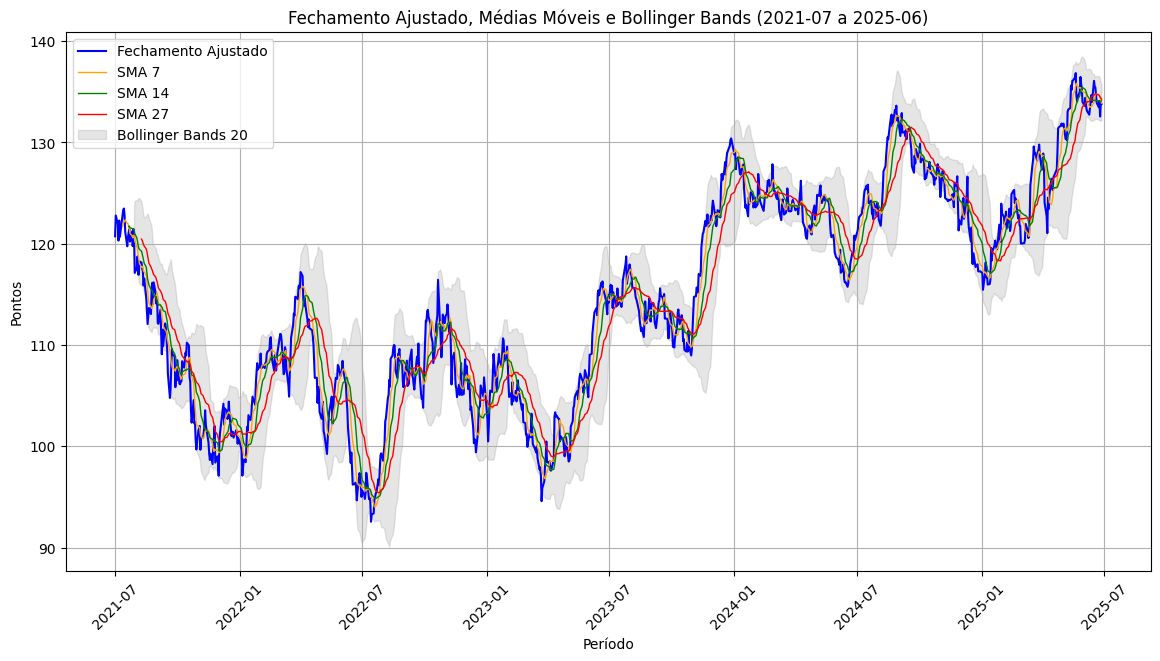

In [53]:
# Começando com visualições

import matplotlib.pyplot as plt

# Garantir que a data seja o índice
df = df_bova11_new_features.copy()
df.index = pd.to_datetime(df.index)

# Definir período solicitado
data_inicial = "2021-07-01"
data_final = "2025-06-30"
df_periodo = df.loc[data_inicial:data_final].copy()

# Calcular Bollinger Bands (média ± 2*desvio)
bb_mean = df_periodo['fechamento_ajustado'].rolling(20).mean()
bb_std = df_periodo['fechamento_ajustado'].rolling(20).std()
bb_upper = bb_mean + 2 * bb_std
bb_lower = bb_mean - 2 * bb_std

# Criar gráfico
plt.figure(figsize=(14, 7))

# Preço
plt.plot(df_periodo.index, df_periodo['fechamento_ajustado'], label="Fechamento Ajustado", color="blue", linewidth=1.5)

# Médias móveis
plt.plot(df_periodo.index, df_periodo['SMA_7'], label="SMA 7", color="orange", linewidth=1)
plt.plot(df_periodo.index, df_periodo['SMA_14'], label="SMA 14", color="green", linewidth=1)
plt.plot(df_periodo.index, df_periodo['SMA_27'], label="SMA 27", color="red", linewidth=1)

# Bollinger Bands
plt.fill_between(df_periodo.index, bb_lower, bb_upper, color="gray", alpha=0.2, label="Bollinger Bands 20")

# Ajustes do gráfico
plt.title("Fechamento Ajustado, Médias Móveis e Bollinger Bands (2021-07 a 2025-06)")
plt.xlabel("Período")
plt.ylabel("Pontos")
plt.legend(loc="best")
plt.grid(True)
plt.xticks(rotation=45)

plt.show()
